## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [ ]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 325 entries, 0 to 343
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              325 non-null    object 
 1   Island               325 non-null    object 
 2   Clutch Completion    325 non-null    object 
 3   Date Egg             325 non-null    int64  
 4   Culmen Length (mm)   325 non-null    float64
 5   Culmen Depth (mm)    325 non-null    float64
 6   Flipper Length (mm)  325 non-null    float64
 7   Body Mass (g)        325 non-null    float64
 8   Sex                  325 non-null    object 
 9   Delta 15 N (o/oo)    325 non-null    float64
 10  Delta 13 C (o/oo)    325 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 30.5+ KB


In [ ]:
data.isna().sum()

,0
Species,0
Island,0
Clutch Completion,0
Date Egg,0
Culmen Length (mm),0
Culmen Depth (mm),0
Flipper Length (mm),0
Body Mass (g),0
Sex,0
Delta 15 N (o/oo),0


Ясно из описания переменных, что категориальными являются наша целевая переменная, остров, завершенность кладки яиц и пол. Завершенность кладки и пол кодирются простыми да/нет и мужчина/женщина соответсвенно, так что тут можно просто задать биномиальнумю переменную 0 1. Про целевую переменную сказано ниже, а остров кажется разумным кодировать через get_dummies, ведь у нас больше, чем 2 признака, поэтому необходим по сути onehotencoder, но у нас не должны появится новые признаки тк дф про пингвинов всего один, так что хватит простого pandas, пока без skylearn

In [ ]:
data['Sex'] = np.where(data['Sex']=='MALE', 1, 0)
data['Clutch Completion'] = np.where(data['Clutch Completion']=='Yes', 1, 0)
d = pd.get_dummies(data['Island'], drop_first=True)
data = pd.concat([data, d], axis=1)
data = data.drop('Island', axis=1)

Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

https://habr.com/ru/companies/karuna/articles/769366/ шаблон кода для OrdinalEncoder

In [ ]:
penguins = ['Chinstrap', 'Gentoo', 'Adelie']
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories = [penguins])
data['Species'] = encoder.fit_transform(data[['Species']])
data

,Species,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Dream,Torgersen
0,0.0,1,382,50.9,19.1,196.0,3550.0,1,10.02372,-24.86594,True,False
1,0.0,1,741,45.2,17.8,198.0,3950.0,0,8.88942,-24.49433,True,False
2,1.0,1,744,46.5,13.5,210.0,4550.0,0,7.99530,-25.32829,False,False
3,0.0,1,10,45.2,16.6,191.0,3250.0,0,9.62357,-24.78984,True,False
4,1.0,1,13,48.4,14.4,203.0,4625.0,0,8.16582,-26.13971,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
339,0.0,1,382,47.6,18.3,195.0,3850.0,0,8.83502,-24.65859,True,False
340,2.0,1,382,39.7,18.4,190.0,3900.0,1,9.29808,-25.23453,False,True
341,2.0,1,16,38.6,17.2,199.0,3750.0,0,8.77322,-26.48973,False,False
342,1.0,1,392,46.6,14.2,210.0,4850.0,0,8.38289,-26.86352,False,False


In [ ]:
y = data['Species']
x = data.drop('Species', axis=1)

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [ ]:
from sklearn.model_selection import train_test_split
np.random.seed(52)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y)

Это важно для несбалансированных данных, может так оказаться (мы не проверяли), что каких-то пингвинов больше, но ввиду случайного разбиения в test у нас окажется не такое же разделение, по сути мы може проверять нашу модель например практически полносью на самом непопулярном значении, чтобы этого избежать и зафиксировать пропорции мы и будем использовать stratify

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [ ]:
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_1_train = X_train[['Body Mass (g)', 'Flipper Length (mm)']]
X_1_test = X_test[['Body Mass (g)', 'Flipper Length (mm)']]
normalizer = preprocessing.StandardScaler()
X_train_norm = normalizer.fit_transform(X_1_train)
X_test_norm = normalizer.transform(X_1_test)
X_train = pd.DataFrame(data=X_train_norm, columns=X_1_train.columns)
X_test = pd.DataFrame(data=X_test_norm, columns=X_1_test.columns)

print('NN', 'Train', 'Test')
clsf=[]
for k in [1, 3, 5, 10, 15, 25]:
  clf = KNeighborsClassifier(n_neighbors=k)
  clf.fit(X_train, y_train)
  clsf.append(clf)
  y_predicted = clf.predict(X_train)
  train_a = accuracy_score(y_train, y_predicted)
  y_predicted = clf.predict(X_test)
  test_a = accuracy_score(y_test, y_predicted)
  print(k, round(train_a, 2), round(test_a, 2))

NN Train Test
1 0.96 0.77
3 0.85 0.79
5 0.83 0.79
10 0.8 0.84
15 0.81 0.84
25 0.8 0.82


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [ ]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [ ]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/pytho

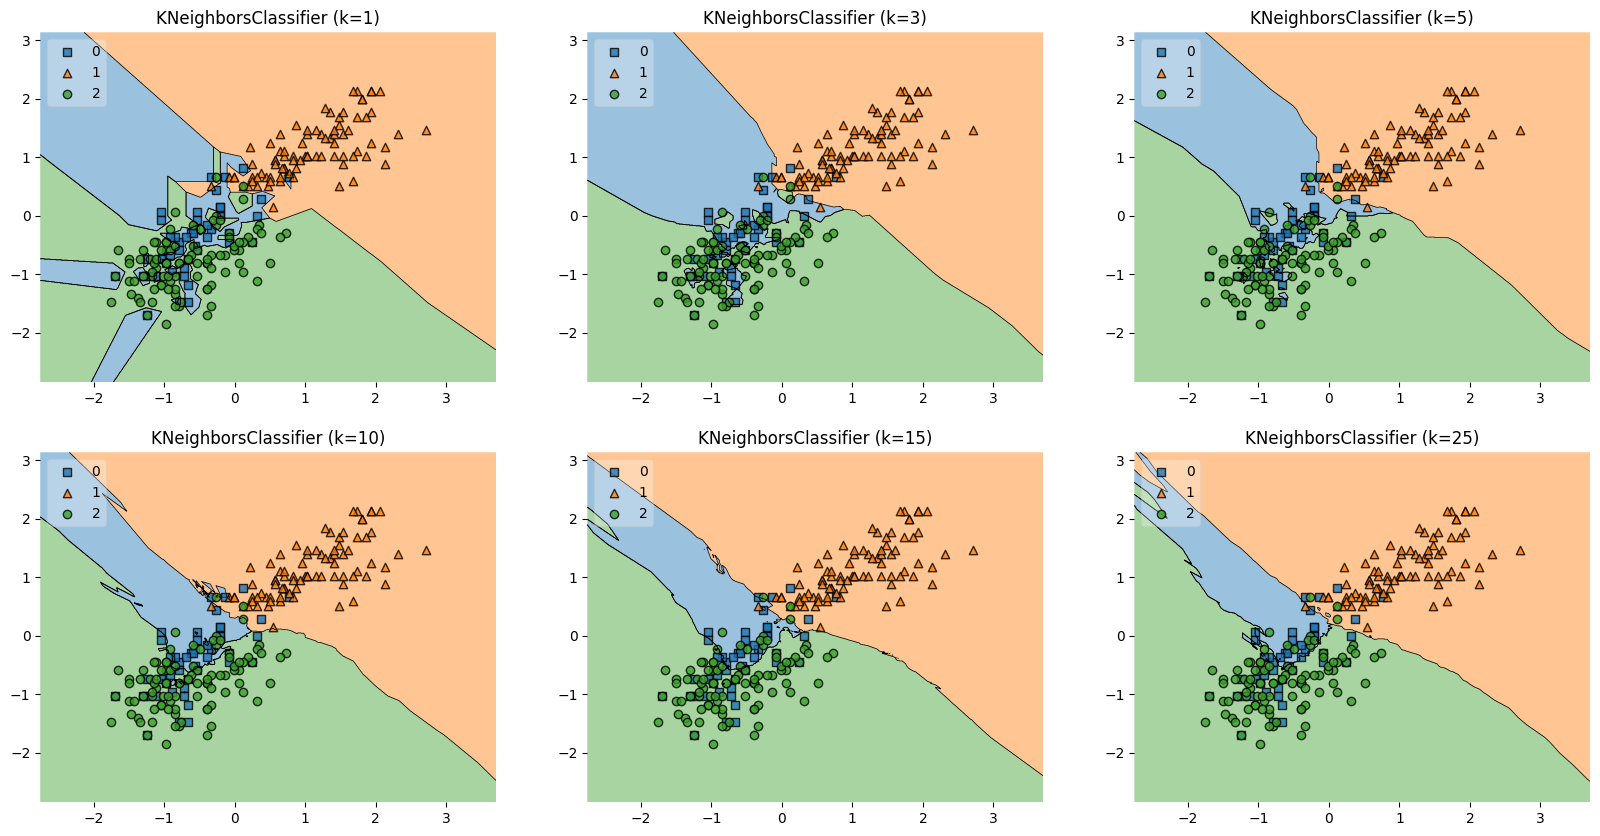

In [ ]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
gs = gridspec.GridSpec(2, 3)

fig = plt.figure(figsize=(20,10))

labels = ['KNeighborsClassifier (k=1)', 'KNeighborsClassifier (k=3)', 'KNeighborsClassifier (k=5)', 'KNeighborsClassifier (k=10)', 'KNeighborsClassifier (k=15)', 'KNeighborsClassifier (k=25)']
for clf, lab, grd in zip(clsf,
                         labels,
                         itertools.product([0, 1], [0, 1, 2])):
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=np.array(X_train_norm), y=np.array(y_train).astype(np.int_), clf=clf, legend=2)
    plt.title(lab)

plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

Оптимально будет использовать 15 соседей. Если говорить, про наши результаты на train и test, то можно заметить, что у этого случая, во-первых, самое высокое качество на test, во-вторых, качесто на train не сильно уступает, вероятно, если уже дальше увеличивать количество соседей, то станет только хуже, как в слуае с 25. Тут также стоит оговориться, что мы рассмаривает результаты именно с random_state = 52, при других значениях можно прийти к другим выводам. В случае с 15 мы имеем выский результат на train и не большой разрыв между train и test, что значит, что в целом высокий результат будет ожидаем, если бы отдадим на тест другую часть выборки. Касаемо графиков видно, что график 10, 15, 25 в целом очень схож (как и результаты на train и test), в целом тут все эти 3 графика достаточно корректно отображают распределение классов, не стоят четкие границы, распределение относительно плавное, видно, что синяя область занимает меньшую часть графика. Очевидно резульаьты с 1 соседом говорят о переобучении, гиганский разрыв между train и test указывает на это и четкие раницы на графике. В случае с 3 и 5 можно предпологать о признаках переобучения, но разница в доле верных ответов не является такой большой, а графики просто не так корректно отображаю несбалансированность классов, но резких грниц явно нет

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

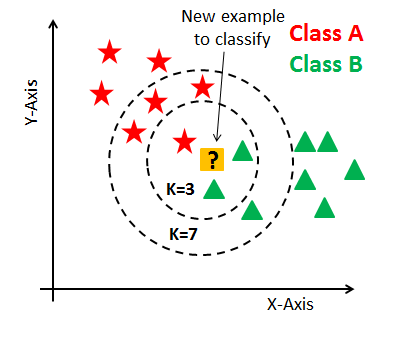

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [ ]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        self.k = k

    def fit(self, X, y):

      # YOUR CODE HERE
      # (⌒_⌒;)
      self.X_train = np.array(X)
      self.y_train = np.array(y)

    def predict(self, X):

      # YOUR CODE HERE
      # (＠_＠)
      X_test = np.array(X)
      result = list()
      for el in X_test:
        result.append(self.count_distance(el, self.X_train))
      return np.array(result)


    def count_distance(self, x, y):

      # YOUR CODE HERE
      # ヽ(♡‿♡)ノ
      distances = np.linalg.norm(y - x, axis=1)
      ind = np.argsort(distances)[:self.k]
      counter = Counter(self.y_train[ind])
      return counter.most_common(1)[0][0]

In [ ]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [ ]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [ ]:
result = list()
for k in [1, 3, 5, 10, 15, 25]:
  knn = KNN(k=k)
  knn.fit(X_train, y_train)
  y_predicted=knn.predict(X_test)
  result.append(accuracy_score(y_test, y_predicted))
print(max(result))

0.8367346938775511


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [ ]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [ ]:
data = data.dropna()
data = data.drop('Unnamed: 0', axis=1)
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


первый столбец, который был изначально просто повторял номер строки и не нес в себе никакой информации, поэтому удалили его

**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [ ]:
data.corr(numeric_only=True)

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


Видно, что значимо коррелируют карат и все 3 грани камня

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [ ]:
d = pd.get_dummies(data['cut'], drop_first=True)
data = pd.concat([data, d], axis=1)
data = data.drop('cut', axis=1)

d = pd.get_dummies(data['color'], drop_first=True)
data = pd.concat([data, d], axis=1)
data = data.drop('color', axis=1)

d = pd.get_dummies(data['clarity'], drop_first=True)
data = pd.concat([data, d], axis=1)
data = data.drop('clarity', axis=1)

**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [ ]:
x=data.drop('price', axis=1)
y=data['price']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [ ]:
from sklearn import preprocessing
normalizer = preprocessing.StandardScaler()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)
X_train = pd.DataFrame(data=X_train_norm, columns=X_train.columns)
X_test = pd.DataFrame(data=X_test_norm, columns=X_test.columns)

как уже сказано мы не можем просто говорить об изменении значения на единицу, теперь мы гворим об изменении отмаштабированных признаков, тк тут использовали StandardScaler, то об изменении стандартного отколнения. Благодря этому мы не будем получать для всех признаков разные интерпртиации, то есть что-то измеряется в см, что-то в граммах, теперь все на равных и мы измеряем в стандартных отклонениях

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

https://habr.com/ru/articles/804135/ отсюда взят шаблон для регрессии

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
sk_linear_regression = LinearRegression()
sk_linear_regression.fit(X_train, y_train)
sk_lr_pred_res = sk_linear_regression.predict(X_train)
print('на train',  mean_squared_error(y_train, sk_lr_pred_res))
sk_lr_pred_res = sk_linear_regression.predict(X_test)
print('на test',  mean_squared_error(y_test, sk_lr_pred_res))

на train 1290541.9147450614
на test 1244765.4357158695


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [ ]:
print(sk_linear_regression.coef_)
data.info() #это чтобы посмотреть какие вещественные

[ 5338.61567061   -90.17381703   -60.33227991 -1100.41885004
    -6.45891672   -34.25894462   170.60293265   414.36951486
   339.23920411   310.65425625   -83.64002086  -104.56099268
  -202.86356354  -362.00229958  -442.78356742  -529.44921589
   975.93364117  1611.5716809   1042.92121499  1670.31849636
  1817.66420828  1284.80947523  1461.03419387]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   carat      53940 non-null  float64
 1   depth      53940 non-null  float64
 2   table      53940 non-null  float64
 3   price      53940 non-null  int64  
 4   x          53940 non-null  float64
 5   y          53940 non-null  float64
 6   z          53940 non-null  float64
 7   Good       53940 non-null  bool   
 8   Ideal      53940 non-null  bool   
 9   Premium    53940 non-null  bool   
 10  Very Good  53940 non-null  bool   
 11  E          539

Коэффиценты перед каратом и х-гранью на порядок превышают оценки у и z граней и depth и table

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [ ]:
from sklearn import linear_model
reg = linear_model.Lasso(alpha=10)
reg.fit(X_train, y_train)
reg.coef_

array([4831.59626086,  -96.51685344,  -71.93794363, -651.18519277,
         -0.        ,  -28.49475941,   46.13596549,  206.83767582,
        151.39127079,  139.24149436,  -12.10568106,  -37.37333901,
       -123.6378664 , -285.767992  , -368.87614678, -469.2676605 ,
        661.82943428,  875.5658754 ,  408.43340368, 1047.87685969,
       1099.90885795,  848.81716871,  959.29856886])

In [ ]:
reg = linear_model.Ridge(alpha=10)
reg.fit(X_train, y_train)
reg.coef_

array([ 5299.36046069,   -88.38302464,   -60.57679601, -1057.321756  ,
          -9.14802499,   -37.56886358,   171.20336413,   415.48016859,
         340.21593369,   312.01606582,   -83.21928024,  -104.38686434,
        -202.29344358,  -360.99775436,  -441.42772206,  -528.13069178,
         963.39852302,  1580.72064771,  1016.7986878 ,  1644.55161501,
        1787.75171653,  1267.17953038,  1440.49036818])

В Лассо достаточно сильно снизился коэффицент перед x-гранью, в Редж изменения не значительные. Исодя из данных по Лассо можно сделать выводы о наличии мультиколлениарности х с другими признаками, также можно заметить, что коэффицент при у-грани Лассо вообще обнулил, что тоже указвает на вероятную мультиколлениарность, но учитывая, что Рижд не так сильно изменил коэффиценты, следует предполагать, что это не сильная мультиколлениарность

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

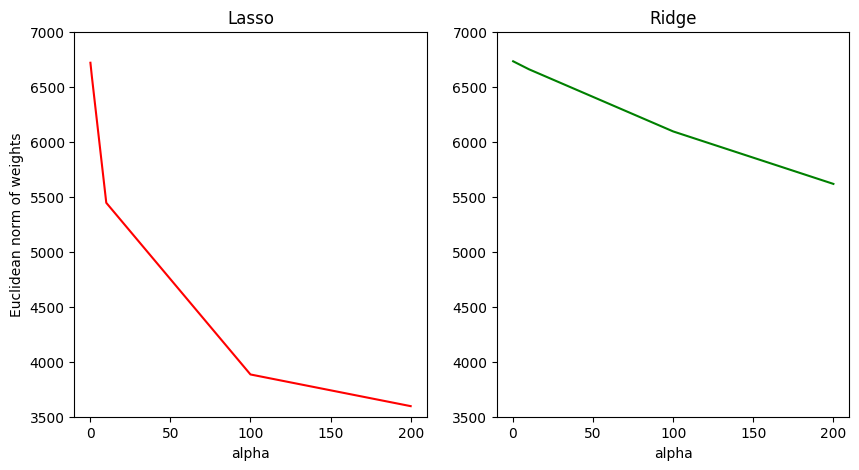

In [ ]:
alpha=[0.1, 1, 10, 100, 200]
dic=dict()
dic2=dict()
for a in alpha:
  reg = linear_model.Lasso(alpha=a)
  reg.fit(X_train, y_train)
  dic[a]=np.linalg.norm(reg.coef_)
for a in alpha:
  reg = linear_model.Ridge(alpha=a)
  reg.fit(X_train, y_train)
  dic2[a]=np.linalg.norm(reg.coef_)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(dic.keys(), dic.values(), color='red')
plt.ylim(3500, 7000)
plt.title('Lasso')
plt.xlabel('alpha')
plt.ylabel('Euclidean norm of weights')

plt.subplot(1, 2, 2)
plt.plot(dic2.keys(), dic2.values(), color='green')
plt.ylim(3500, 7000)
plt.title('Ridge')
plt.xlabel('alpha')
plt.show()

Из графика видно, что Lasso намного сильнее снижает норму коэффицентов, особенно при увеличении альфы, именно поэтому Lasso-регрессию часто используют для отбора признаков, с ее помощью можно сильнее снижать значения коэффицентов, по сранению с Ridge-регрессией

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [ ]:
from sklearn.linear_model import LassoCV
reg = LassoCV(alphas = [0.1, 1, 10, 100, 200], cv=5, max_iter=20000)
reg.fit(X_train, y_train)
matr = reg.mse_path_
min_mse = np.argmin(np.mean(matr, axis=1))
print(reg.alphas_[min_mse])

1.0


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [ ]:
reg = linear_model.Lasso(alpha=1)
reg.fit(X_train, y_train)
print(reg.coef_)

[ 5.28773453e+03 -9.07213828e+01 -6.14634345e+01 -1.05885265e+03
 -1.83234193e+00 -3.40717932e+01  1.58205512e+02  3.93738780e+02
  3.20598599e+02  2.93580822e+02 -7.64896507e+01 -9.78484183e+01
 -1.94942737e+02 -3.54384836e+02 -4.35389550e+02 -5.23426954e+02
  9.44114162e+02  1.53701718e+03  9.78648513e+02  1.60728046e+03
  1.74497111e+03  1.24065255e+03  1.41022109e+03]


По итогу самый существенный признак это карат, что ожидаемо, ведь на ценность камня влияет его вес. Также грань X осталась очень значимой, y грань практически равна 0, z грань тоже не имеет большое значение, вероятно это связано с тем, что чаще всего увеличение одной грани ведет за обой увеличение других, поэтому размер определятся в большей степени одной из них. depth и table, которые описывают особенности огранки тоже имеют сравнительно не большие коэффиценты. Касаемо категориальных признаков, качество резки в целом имеет влияение, но сильной зависимости от категории нет, с цветом и прозрачностью ситуация немного другая, категории имеют разницу на порядок, сам же цвет не является таким же значимым признаком как прозрачность. Итого, самыми информативными является карат, х-грань и прозрачность, остальные не так влияетельны

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

*вероятно имеется ввиду 3.6?

In [ ]:
lasso_predict = reg.predict(X_test)
mean_squared_error(y_test, lasso_predict)

1243963.1436531865

Лассо оказалась лучше, как раз благодаря тому, что мы устранили мультиколлениарность, а также уменьшила переобучение, ведь теперь ошибка на тесте меньше